# 📏 Étape 3 — Baseline Persistence

Avant d'entraîner des modèles complexes, on établit une **baseline** : le score minimum à battre.

La baseline **persistence** est le modèle le plus naïf possible :
> *« Le niveau dans 10 minutes sera le même qu'aujourd'hui. »*

$$\hat{y}(t + H) = y(t)$$

C'est un benchmark très pertinent pour les séries temporelles à forte autocorrélation (comme un niveau de réservoir qui évolue lentement).  
Si un modèle ML ne fait pas **au moins -20% de MAE/RMSE** par rapport à cette baseline, il n'apporte pas grand chose.

On calcule aussi une **baseline moyenne** (prédire toujours la moyenne du train) pour avoir un second point de référence.

## 1. Imports et chargement des données préprocessées

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

HORIZON = 600   # 10 minutes en secondes (données à 1Hz)
SAVE_DIR = "preprocessed"


In [4]:
# Chargement des données tabulaires produites à l'étape 2
X_train = np.load(f'{SAVE_DIR}/X_train.npy')
X_test  = np.load(f'{SAVE_DIR}/X_test.npy')
y_train = np.load(f'{SAVE_DIR}/y_train.npy')   # valeurs réelles (non normalisées)
y_test  = np.load(f'{SAVE_DIR}/y_test.npy')

ts_train = pd.read_csv(f'{SAVE_DIR}/ts_train.csv', parse_dates=[0]).iloc[:, 0]
ts_test  = pd.read_csv(f'{SAVE_DIR}/ts_test.csv',  parse_dates=[0]).iloc[:, 0]

feature_cols = pd.read_csv(f'{SAVE_DIR}/feature_cols.csv').iloc[:, 0].tolist()

print(f"Train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"Test  : {X_test.shape}   |  y_test  : {y_test.shape}")
print(f"Nombre de features : {len(feature_cols)}")

Train : (627152, 366)  |  y_train : (627152,)
Test  : (156789, 366)   |  y_test  : (156789,)
Nombre de features : 366


## 2. Récupération de la valeur actuelle (t)

La baseline persistence prédit `y(t+H) = y(t)`.  
La valeur `y(t)` correspond à la colonne `1_LT_001_PV` dans les features (lag 0 = valeur actuelle).  
On l'extrait directement depuis `X_test`.

In [5]:
# Reconstruction du datetime (Row = 1 seconde)
TARGET = "1_LT_001_PV"
target_idx = feature_cols.index(TARGET)
print(f"Index de {TARGET} dans les features : {target_idx}")

import pandas as pd
df_raw = pd.read_csv("WADI_14days_new.csv")
START_TIME = pd.Timestamp("2017-09-25 00:00:00")
df_raw["datetime"] = START_TIME + pd.to_timedelta(df_raw["Row"] - 1, unit="s")
df_raw = df_raw.drop(columns=["Row", "Date", "Time"], errors="ignore")
for col in df_raw.columns:
    if col != "datetime":
        df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")
df_raw = df_raw.set_index("datetime").sort_index()

# Valeur de TARGET aux timestamps du test (index en secondes)
y_current = df_raw[TARGET].reindex(ts_test).values

print(f"y_current shape : {y_current.shape}")
print(f"y_test    shape : {y_test.shape}")

mask = ~np.isnan(y_current) & ~np.isnan(y_test)
y_current = y_current[mask]
y_true    = y_test[mask]
ts_eval   = ts_test.values[mask]
print(f"Points evaluation valides : {mask.sum():,}")


Index de 1_LT_001_PV dans les features : 0
y_current shape : (156789,)
y_test    shape : (156789,)
Points evaluation valides : 156,789


## 3. Calcul des métriques

On utilise trois métriques :

| Métrique | Formule | Interprétation |
|----------|---------|----------------|
| **MAE** | $\frac{1}{n}\sum|y - \hat{y}|$ | Erreur moyenne absolue (même unité que le niveau) |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y-\hat{y})^2}$ | Pénalise plus les grosses erreurs |
| **Skill score** | $1 - \frac{RMSE_{model}}{RMSE_{persistence}}$ | % d'amélioration vs persistence (>0 = meilleur) |

Le **skill score** sera la référence principale pour comparer tous les modèles.

In [6]:
def compute_metrics(y_true, y_pred, label='Modèle', rmse_ref=None):
    """Calcule MAE, RMSE et Skill score vs une référence."""
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    skill = (1 - rmse / rmse_ref) * 100 if rmse_ref is not None else None

    print(f"{'─'*40}")
    print(f" {label}")
    print(f"{'─'*40}")
    print(f"  MAE   : {mae:.4f}")
    print(f"  RMSE  : {rmse:.4f}")
    if skill is not None:
        sign = '+' if skill >= 0 else ''
        print(f"  Skill : {sign}{skill:.2f}% vs persistence")
    print()
    return {'label': label, 'MAE': mae, 'RMSE': rmse, 'Skill': skill}

results = []

## 4. Baseline Persistence

Prédiction : `ŷ(t+10) = y(t)` — on recopie simplement la valeur courante.

**Résultat attendu :** MAE et RMSE de référence. Ce sont les scores que tous les modèles suivants devront dépasser de -20% minimum.

In [7]:
y_pred_persistence = y_current

res_persistence = compute_metrics(y_true, y_pred_persistence, label=f'Persistence (t → t+{HORIZON})')
rmse_persistence = res_persistence['RMSE']
results.append(res_persistence)

print(f"⚠️  Seuil à battre (-20%) :")
print(f"   MAE  < {res_persistence['MAE'] * 0.8:.4f}")
print(f"   RMSE < {rmse_persistence * 0.8:.4f}")

────────────────────────────────────────
 Persistence (t → t+600)
────────────────────────────────────────
  MAE   : 4.2574
  RMSE  : 6.1028

⚠️  Seuil à battre (-20%) :
   MAE  < 3.4059
   RMSE < 4.8822


## 5. Baseline Moyenne

Prédiction : `ŷ = mean(y_train)` — on prédit toujours la même valeur (la moyenne de l'entraînement).  
C'est une baseline encore plus basique, utile pour vérifier que persistence est bien supérieure.

In [8]:
y_pred_mean = np.full_like(y_true, fill_value=np.mean(y_train))

res_mean = compute_metrics(y_true, y_pred_mean,
                           label='Moyenne train (naive)',
                           rmse_ref=rmse_persistence)
results.append(res_mean)

────────────────────────────────────────
 Moyenne train (naive)
────────────────────────────────────────
  MAE   : 7.3971
  RMSE  : 8.7148
  Skill : -42.80% vs persistence



## 6. Persistence sur plusieurs horizons

On évalue la baseline pour plusieurs horizons (5, 10, 30 min) pour comprendre à quel point l'erreur croît avec le temps.  
Cela permet aussi de calibrer l'ambition des modèles selon l'horizon choisi.

**Résultat attendu :** courbe RMSE vs horizon — montre la difficulté croissante de la prédiction.

Horizon  1min -> MAE = 0.7671  |  RMSE = 1.3470
Horizon  5min -> MAE = 2.4701  |  RMSE = 4.0145
Horizon 10min -> MAE = 4.2940  |  RMSE = 6.2812
Horizon 15min -> MAE = 5.8705  |  RMSE = 8.0672
Horizon 20min -> MAE = 7.3184  |  RMSE = 9.8556
Horizon 30min -> MAE = 9.5641  |  RMSE = 12.4150


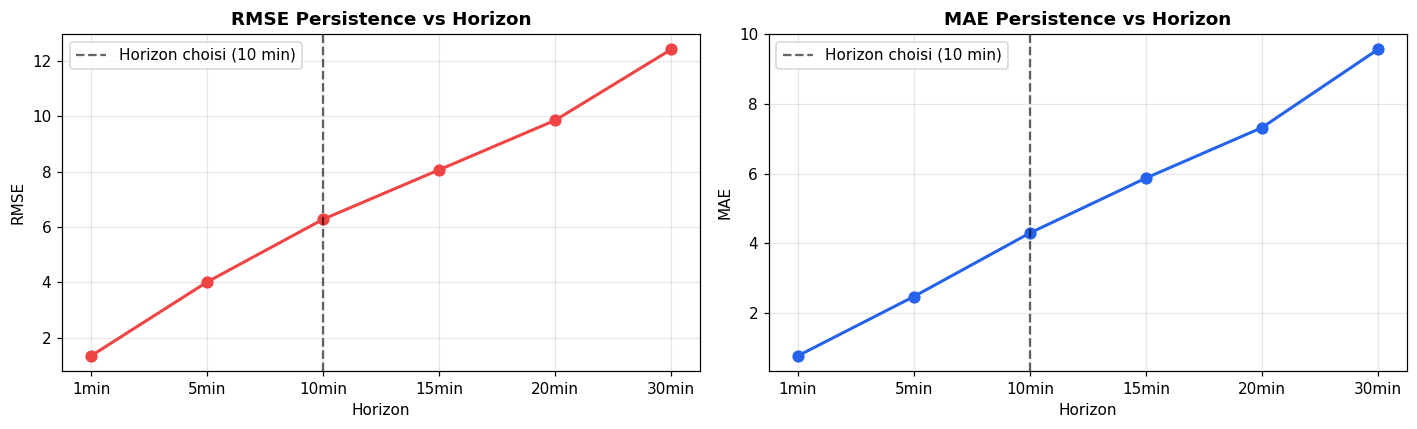

In [9]:
# Horizons en secondes (1min=60, 5min=300, 10min=600, 15min=900, 20min=1200, 30min=1800)
horizons     = [60, 300, 600, 900, 1200, 1800]
horizons_lbl = ["1min", "5min", "10min", "15min", "20min", "30min"]
horizon_rmse = []
horizon_mae  = []

target_series = df_raw[TARGET].dropna()

for h, lbl in zip(horizons, horizons_lbl):
    y_now  = target_series.values[:-h]
    y_fut  = target_series.values[h:]
    mae_h  = np.mean(np.abs(y_fut - y_now))
    rmse_h = np.sqrt(np.mean((y_fut - y_now) ** 2))
    horizon_rmse.append(rmse_h)
    horizon_mae.append(mae_h)
    print(f"Horizon {lbl:>5} -> MAE = {mae_h:.4f}  |  RMSE = {rmse_h:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(horizons_lbl, horizon_rmse, "o-", color="#EF4444", linewidth=2, markersize=7)
axes[0].axvline("10min", color="black", linestyle="--", alpha=0.6, label="Horizon choisi (10 min)")
axes[0].set_xlabel("Horizon")
axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE Persistence vs Horizon", fontsize=12, fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(horizons_lbl, horizon_mae, "o-", color="#2563EB", linewidth=2, markersize=7)
axes[1].axvline("10min", color="black", linestyle="--", alpha=0.6, label="Horizon choisi (10 min)")
axes[1].set_xlabel("Horizon")
axes[1].set_ylabel("MAE")
axes[1].set_title("MAE Persistence vs Horizon", fontsize=12, fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Visualisation des prédictions

On visualise la prédiction persistence vs la vérité sur un extrait du test pour comprendre visuellement où elle se trompe.  
La persistence a tendance à rater les **changements brusques** (activations de pompes, ouvertures de vannes).

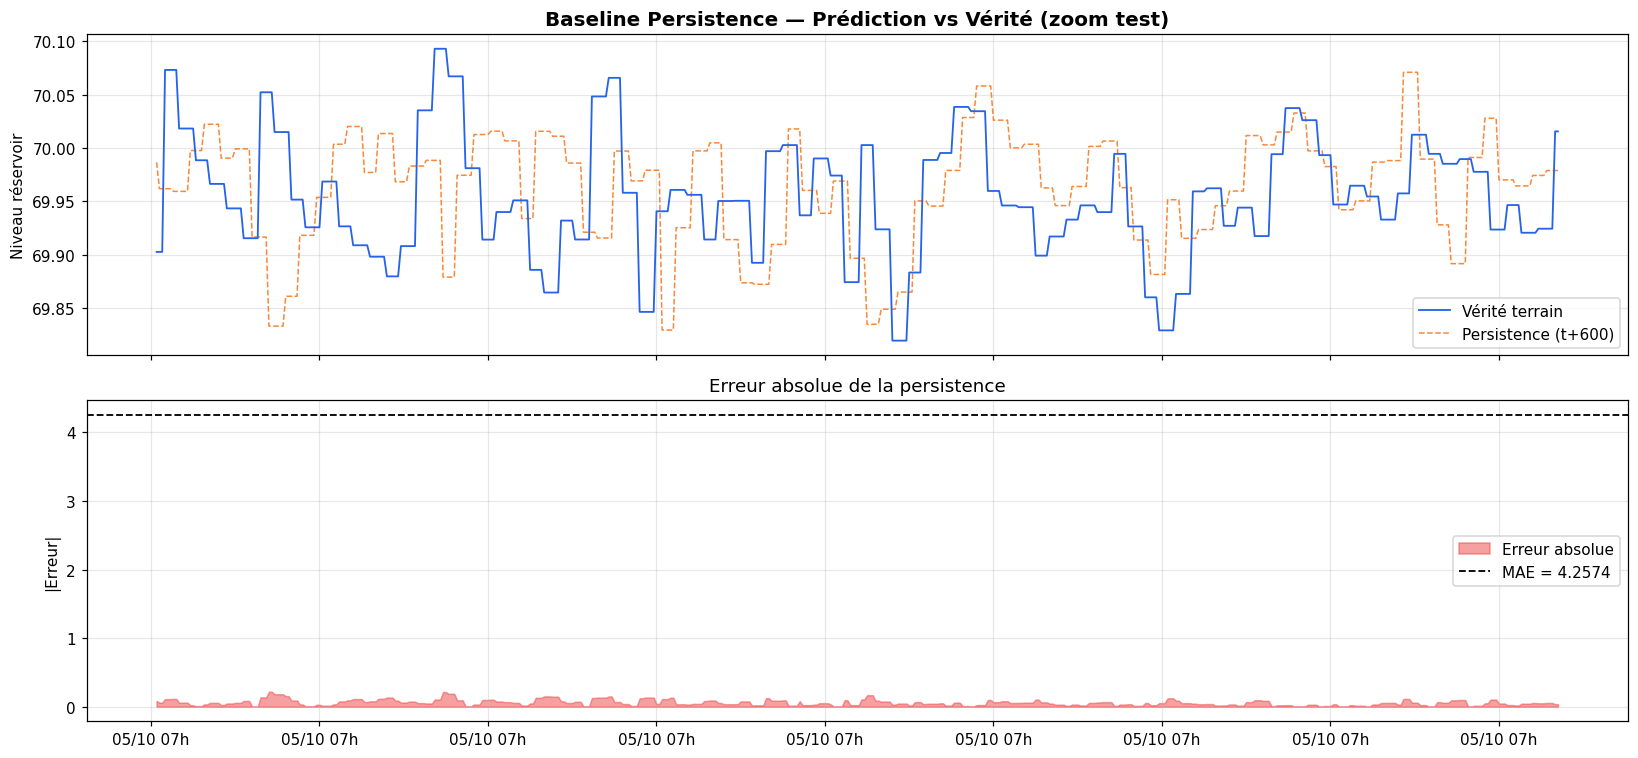

In [10]:
# Zoom sur 500 points du test pour lisibilité
N_PLOT = 500
ts_plot = pd.to_datetime(ts_eval[:N_PLOT])

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

# ── Subplot 1 : prédiction vs vérité ─────────────────────────────────────────
axes[0].plot(ts_plot, y_true[:N_PLOT],              color='#2563EB', linewidth=1.2,
             label='Vérité terrain', zorder=3)
axes[0].plot(ts_plot, y_pred_persistence[:N_PLOT],  color='#F97316', linewidth=1,
             linestyle='--', label=f'Persistence (t+{HORIZON})', alpha=0.85)
axes[0].set_ylabel('Niveau réservoir')
axes[0].set_title('Baseline Persistence — Prédiction vs Vérité (zoom test)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Subplot 2 : erreur absolue ────────────────────────────────────────────────
error = np.abs(y_true[:N_PLOT] - y_pred_persistence[:N_PLOT])
axes[1].fill_between(ts_plot, error, color='#EF4444', alpha=0.5, label='Erreur absolue')
axes[1].axhline(res_persistence['MAE'], color='black', linestyle='--',
                linewidth=1.2, label=f"MAE = {res_persistence['MAE']:.4f}")
axes[1].set_ylabel('|Erreur|')
axes[1].set_xlabel('')
axes[1].set_title('Erreur absolue de la persistence', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %Hh'))

plt.tight_layout()
plt.show()

## 8. Autocorrélation de la cible

L'autocorrélation mesure à quel point `y(t)` est corrélé avec `y(t-k)` pour différents décalages `k`.  
Une autocorrélation élevée à k=10 explique pourquoi la persistence est une baseline difficile à battre — et indique combien de lags il faut inclure dans les modèles ML.

**Résultat attendu :** voir jusqu'à quel lag l'autocorrélation reste significative.

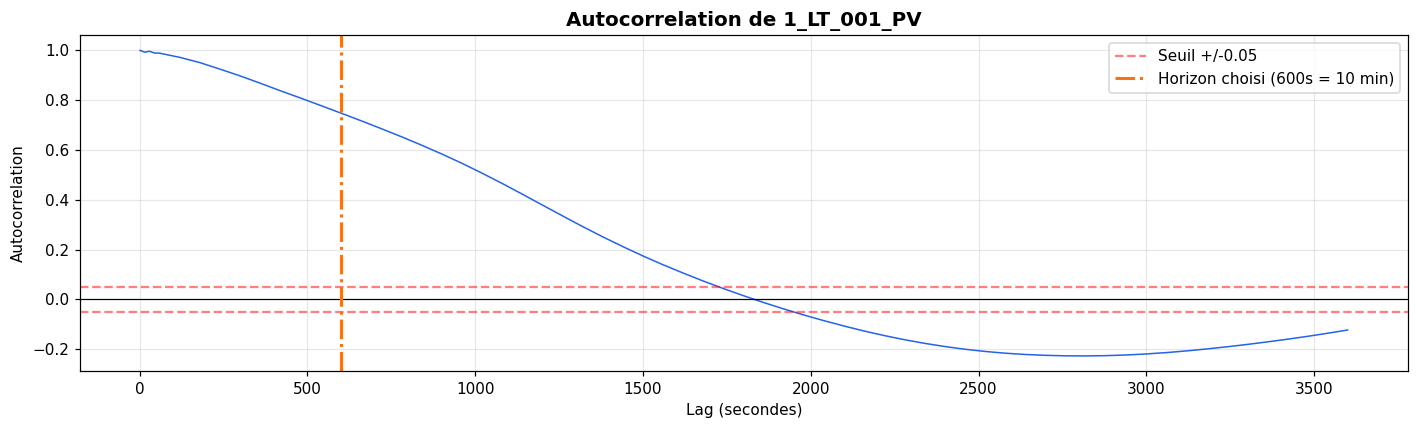

Autocorrelation a lag 600s (= 10 min) : 0.7477529473074486
Autocorrelation a lag 1s                   : 0.9996
Autocorrelation a lag 60s (1 min)          : 0.9884
Autocorrelation a lag 1s                   : 0.9996
Autocorrelation a lag 60s (1 min)          : 0.9884


In [12]:
from pandas.plotting import autocorrelation_plot

target_series_clean = df_raw[TARGET].dropna()

# Lags en secondes — on calcule jusqu'a 3600s (1h)
# On echantillonne pour ne pas calculer 3600 autocorrelations
lags_sec = list(range(1, 61)) + list(range(120, 3601, 60))  # 1-60s puis chaque minute
autocorrs = [target_series_clean.autocorr(lag=k) for k in lags_sec]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(lags_sec, autocorrs, color="#2563EB", linewidth=1)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(0.05,  color="red", linestyle="--", alpha=0.5, label="Seuil +/-0.05")
ax.axhline(-0.05, color="red", linestyle="--", alpha=0.5)
ax.axvline(HORIZON, color="#F97316", linewidth=2, linestyle="-.",
           label=f"Horizon choisi ({HORIZON}s = 10 min)")
ax.set_xlabel("Lag (secondes)")
ax.set_ylabel("Autocorrelation")
ax.set_title("Autocorrelation de 1_LT_001_PV", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

val_horizon = autocorrs[lags_sec.index(HORIZON)] if HORIZON in lags_sec else 'N/A'
print(f"Autocorrelation a lag {HORIZON}s (= 10 min) : {val_horizon}")
print(f"Autocorrelation a lag 1s                   : {autocorrs[0]:.4f}")
print(f"Autocorrelation a lag 60s (1 min)          : {autocorrs[59]:.4f}")
print(f"Autocorrelation a lag 1s                   : {autocorrs[0]:.4f}")
print(f"Autocorrelation a lag 60s (1 min)          : {autocorrs[59]:.4f}")


## 9. Tableau de bord des baselines

On récapitule tous les scores dans un tableau propre et on sauvegarde les résultats pour les comparer avec les modèles ML/DL.

In [13]:
import os

df_results = pd.DataFrame(results)[['label', 'MAE', 'RMSE', 'Skill']]
df_results = df_results.round(4)
df_results.columns = ['Modèle', 'MAE', 'RMSE', 'Skill (%)']
print("=" * 55)
print(" TABLEAU DE BORD — BASELINES")
print("=" * 55)
print(df_results.to_string(index=False))
print("=" * 55)
print(f"\n🎯 Objectif modèles ML/DL :")
print(f"   MAE  < {res_persistence['MAE'] * 0.8:.4f}   (−20% vs persistence)")
print(f"   RMSE < {rmse_persistence * 0.8:.4f}   (−20% vs persistence)")
print(f"   Skill > 20%")

# Sauvegarde pour comparaison future
os.makedirs(SAVE_DIR, exist_ok=True)
df_results.to_csv(f'{SAVE_DIR}/resultats_baselines.csv', index=False)

# Sauvegarde du RMSE de persistence (référence pour le skill score)
np.save(f'{SAVE_DIR}/rmse_persistence.npy', np.array([rmse_persistence]))
np.save(f'{SAVE_DIR}/mae_persistence.npy',  np.array([res_persistence['MAE']]))

print(f"\n✅ Résultats sauvegardés dans '{SAVE_DIR}/resultats_baselines.csv'")
print("→ Prochaine étape : modeles_ml.ipynb (XGBoost / Random Forest)")

 TABLEAU DE BORD — BASELINES
                 Modèle    MAE   RMSE  Skill (%)
Persistence (t → t+600) 4.2574 6.1028        NaN
  Moyenne train (naive) 7.3971 8.7148   -42.7999

🎯 Objectif modèles ML/DL :
   MAE  < 3.4059   (−20% vs persistence)
   RMSE < 4.8822   (−20% vs persistence)
   Skill > 20%

✅ Résultats sauvegardés dans 'preprocessed/resultats_baselines.csv'
→ Prochaine étape : modeles_ml.ipynb (XGBoost / Random Forest)
